In [1]:
import os
import shutil

# --------- PATHS ---------
source_root = r"D:\Automatic ANPR\stereofog_images-20260131T142256Z-3-001\stereofog_images"

target_root = r"D:\Automatic ANPR\defog_dataset"
fogged_dir = os.path.join(target_root, "fogged")
defogged_dir = os.path.join(target_root, "defogged")

os.makedirs(fogged_dir, exist_ok=True)
os.makedirs(defogged_dir, exist_ok=True)

counter = 0

# --------- WALK THROUGH ALL DATE FOLDERS ---------
for folder in sorted(os.listdir(source_root)):
    folder_path = os.path.join(source_root, folder)
    
    if not os.path.isdir(folder_path):
        continue
    
    A_path = os.path.join(folder_path, "A")  # defogged
    B_path = os.path.join(folder_path, "B")  # fogged
    
    if not os.path.exists(A_path) or not os.path.exists(B_path):
        continue

    A_images = sorted(os.listdir(A_path))
    B_images = sorted(os.listdir(B_path))

    for a_img, b_img in zip(A_images, B_images):

        counter += 1

        new_name = f"img_{counter:06d}.jpg"

        # copy fogged image
        shutil.copy(
            os.path.join(B_path, b_img),
            os.path.join(fogged_dir, new_name)
        )

        # copy defogged image
        shutil.copy(
            os.path.join(A_path, a_img),
            os.path.join(defogged_dir, new_name)
        )

print("Done.")
print("Total paired images:", counter)


Done.
Total paired images: 9838


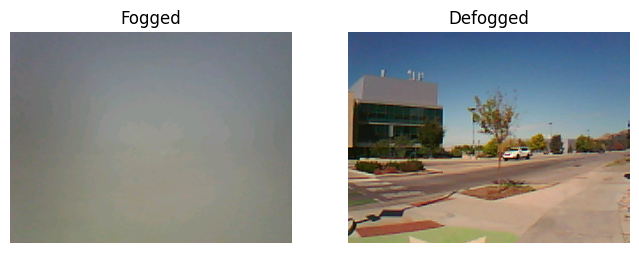

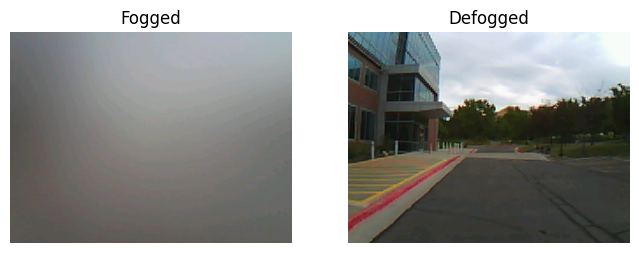

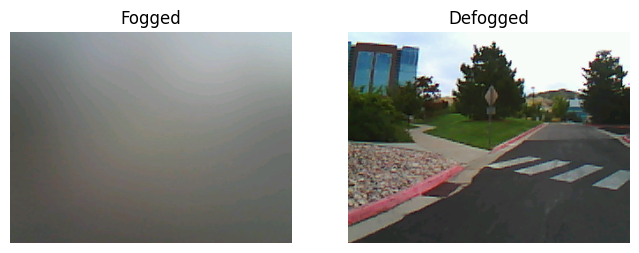

In [2]:
import random
import cv2
import matplotlib.pyplot as plt

fogged_images = os.listdir(fogged_dir)

sample = random.sample(fogged_images, 3)

for name in sample:
    fog = cv2.imread(os.path.join(fogged_dir, name))
    clear = cv2.imread(os.path.join(defogged_dir, name))

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.title("Fogged")
    plt.imshow(cv2.cvtColor(fog, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Defogged")
    plt.imshow(cv2.cvtColor(clear, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.show()
